In [9]:
import subprocess
subprocess.run(['pip', 'install', 'yfinance', '-q'])

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Список акций
tickers = ['AAPL', 'MSFT', 'GOOG', 'NVDA', 'AMZN', 'JNJ']

# Загрузка данных за 5 лет
data = yf.download(tickers, start='2019-01-01', end='2024-01-01')['Close']

print(data.shape)
print(data.head())

/tmp/ipykernel_58/1844129074.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2019-01-01', end='2024-01-01')['Close']
[*********************100%***********************]  6 of 6 completed

(1258, 6)
Ticker           AAPL       AMZN       GOOG         JNJ       MSFT      NVDA
Date                                                                        
2019-01-02  37.469208  76.956497  51.835487  103.791000  94.193130  3.376983
2019-01-03  33.737000  75.014000  50.359005  102.141685  90.727966  3.172957
2019-01-04  35.177200  78.769501  53.067619  103.855965  94.947647  3.376239
2019-01-07  35.098896  81.475502  52.952629  103.189758  95.068726  3.554980
2019-01-08  35.767998  82.829002  53.343681  105.586510  95.758041  3.466478


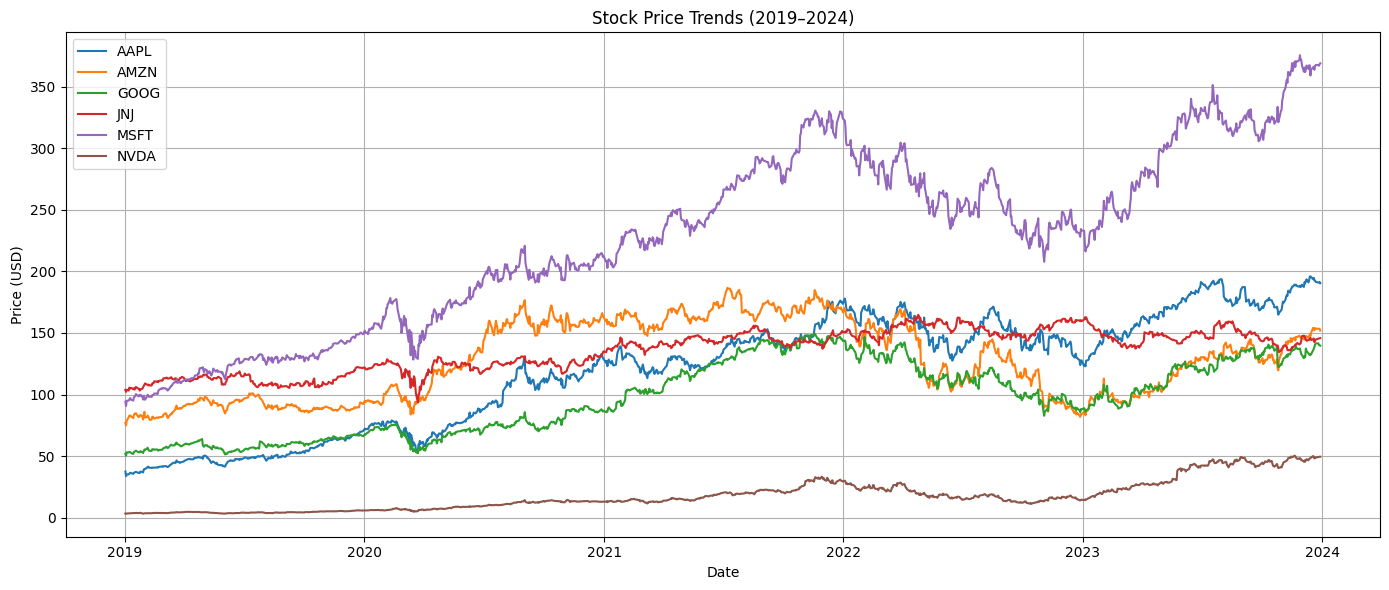

In [10]:
# График 1 — динамика цен всех акций
plt.figure(figsize=(14, 6))
for ticker in data.columns:
    plt.plot(data.index, data[ticker], label=ticker)

plt.title('Stock Price Trends (2019–2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

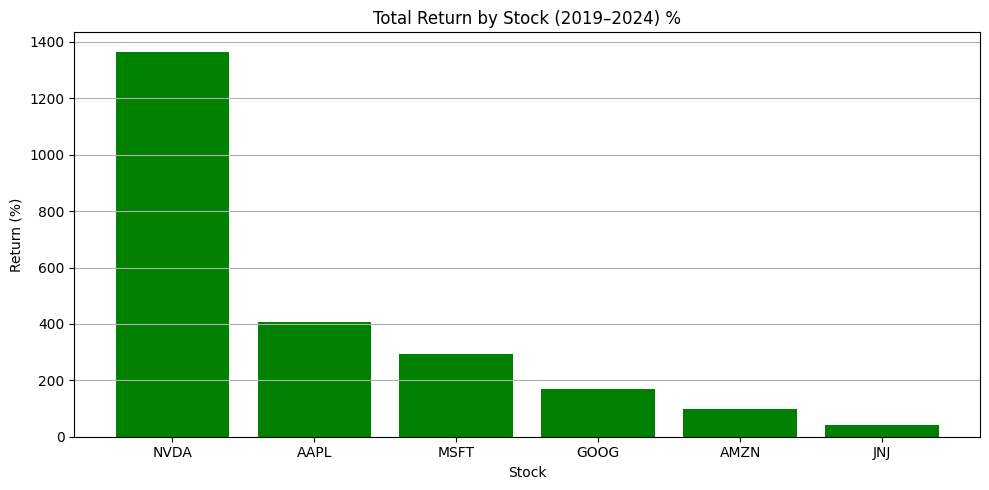

Ticker
NVDA    1365.561129
AAPL     408.084031
MSFT     291.613437
GOOG     169.503241
AMZN      97.436224
JNJ       40.474081
dtype: float64


In [11]:
# Считаем общую доходность за период
returns = ((data.iloc[-1] - data.iloc[0]) / data.iloc[0] * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in returns]
plt.bar(returns.index, returns.values, color=colors)
plt.title('Total Return by Stock (2019–2024) %')
plt.xlabel('Stock')
plt.ylabel('Return (%)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print(returns)

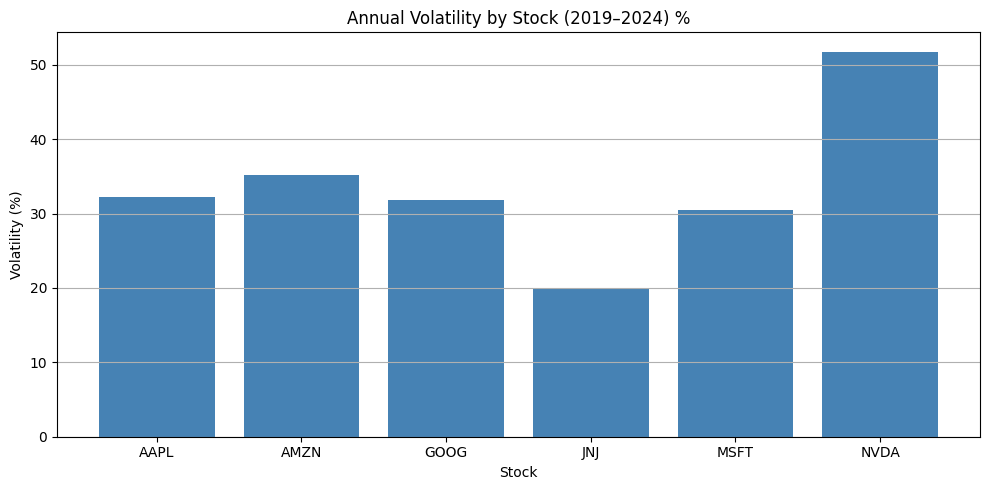

Ticker
AAPL    32.234549
AMZN    35.221391
GOOG    31.818718
JNJ     19.863243
MSFT    30.490851
NVDA    51.769941
dtype: float64


In [12]:
# Считаем волатильность — стандартное отклонение дневных доходностей
daily_returns = data.pct_change().dropna()
volatility = daily_returns.std() * (252 ** 0.5) * 100  # Годовая волатильность

plt.figure(figsize=(10, 5))
plt.bar(volatility.index, volatility.values, color='steelblue')
plt.title('Annual Volatility by Stock (2019–2024) %')
plt.xlabel('Stock')
plt.ylabel('Volatility (%)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print(volatility)

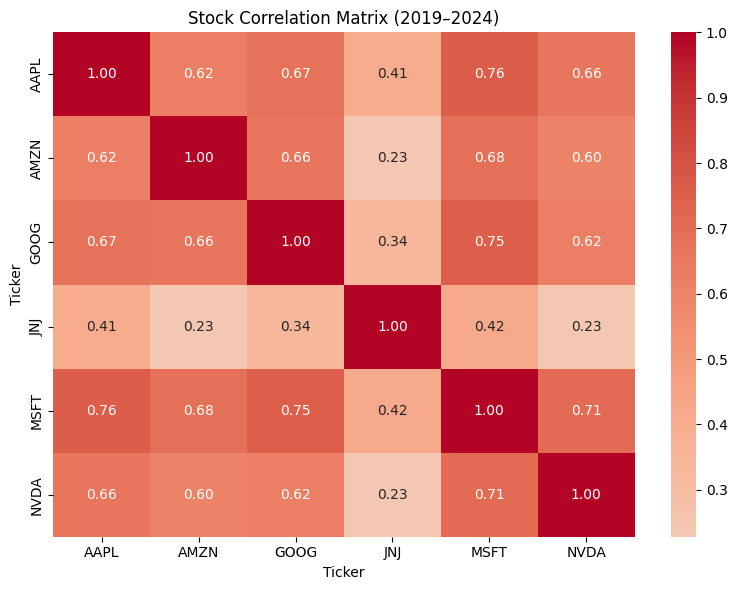

In [13]:
# Корреляция между акциями
corr = daily_returns.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Stock Correlation Matrix (2019–2024)')
plt.tight_layout()
plt.show()

In [14]:
# Экспорт для Power BI
data.to_csv('stock_prices.csv')
daily_returns.to_csv('daily_returns.csv')

print('Файлы сохранены')

Файлы сохранены


In [15]:
# Экспорт с запятой как разделителем для Power BI
data.to_csv('stock_prices_powerbi.csv', decimal=',', sep=';')
print('Готово')

Готово
